# 05 · Gravity in a box & selective resimulation
*A particle-mesh solver validated against linear theory, and the TreePM force split that makes sub-volume resimulation affordable.*

The built-in PM solver (cloud-in-cell deposit → FFT Poisson → kick-drift-kick leapfrog) lets the package exercise gravity without an external N-body code. We *watch* structure grow, verify the growth rate against the exact linear factor D(a), then attack the mini-sim paradox: a resimulated tile cannot feel large-scale tides beyond its buffer — unless the force is split by scale.

In [1]:
%matplotlib inline
import os, sys, json, time, sqlite3, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow, Rectangle, FancyBboxPatch
plt.rcParams.update({'figure.dpi':115,'font.size':10.5,'axes.titlesize':11.5,
    'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,
    'figure.facecolor':'white'})
C0,C1,C2,C3,C4 = '#3a6ea5','#d1495b','#3c8d53','#edae49','#7d5ba6'
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_REAL = EBOSS.exists() and DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
def moll(ax, ra, dec, **kw):
    lon = np.radians(((np.asarray(ra)+180)%360)-180)
    ax.scatter(lon, np.radians(dec), **kw)
print('real eBOSS+DESI available:', HAVE_REAL)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS+DESI available: True


## Watching structure grow — and checking it grows *right*
Four PM runs of the same initial conditions to increasing scale factors. Overlay: the fluctuation amplitude of each snapshot against the exact linear-theory growth factor D(a).

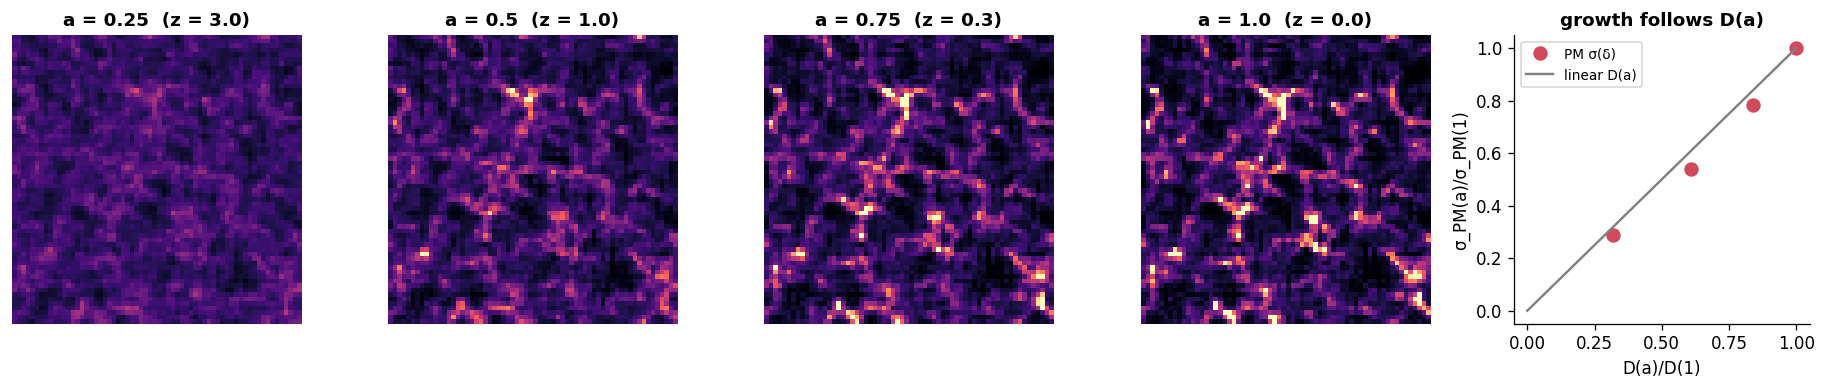

amplitude vs D(a): corr = 0.9950


In [2]:
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
from oneuniverse.simulation.pm.run import run_pm, zeldovich_pm_ic_from_field
from oneuniverse.simulation.pm.deposit import deposit_cic
from oneuniverse.simulation.linear.growth import growth_factor
BOX,N=300.0,64
ic=generate_density_field(COSMO,box_size=BOX,n_grid=N,z=0.0,seed=4)
a_targets=[0.25,0.5,0.75,1.0]
fields=[]
for a_end in a_targets:
    nst=max(6,int(20*a_end))
    x,_=run_pm(*zeldovich_pm_ic_from_field(COSMO,ic,box=BOX,n_grid=N,z_start=9.0),
               box=BOX,n_grid=N,cosmo=COSMO,a_start=0.1,a_end=a_end,n_steps=nst)
    rho=deposit_cic(x,N,BOX); fields.append(rho/rho.mean()-1)
sl=N//2
fig,ax=plt.subplots(1,5,figsize=(16,3.5))
for i,(a,f) in enumerate(zip(a_targets,fields)):
    im=ax[i].imshow(f[:,:,sl].T,origin='lower',cmap='magma',vmin=-1,vmax=4)
    ax[i].set_title(f'a = {a}  (z = {1/a-1:.1f})'); ax[i].axis('off')
D=[growth_factor(1/a-1,COSMO) for a in a_targets]
sig=[f.std() for f in fields]
ax[4].plot(D/np.asarray(D[-1]), sig/np.asarray(sig[-1]),'o',ms=8,color=C1,label='PM σ(δ)')
ax[4].plot([0,1],[0,1],'-',color='.5',label='linear D(a)')
ax[4].set_xlabel('D(a)/D(1)'); ax[4].set_ylabel('σ_PM(a)/σ_PM(1)')
ax[4].set_title('growth follows D(a)'); ax[4].legend(fontsize=8.5)
plt.tight_layout(); plt.show()
r=np.corrcoef(D,sig)[0,1]; print('amplitude vs D(a): corr = %.4f'%r)

## Phases and amplitude: the field-validation estimators
The package's canonical estimators — cross-correlation r(k) (phases) and transfer T(k) (amplitude) — against the z=0 linear field.

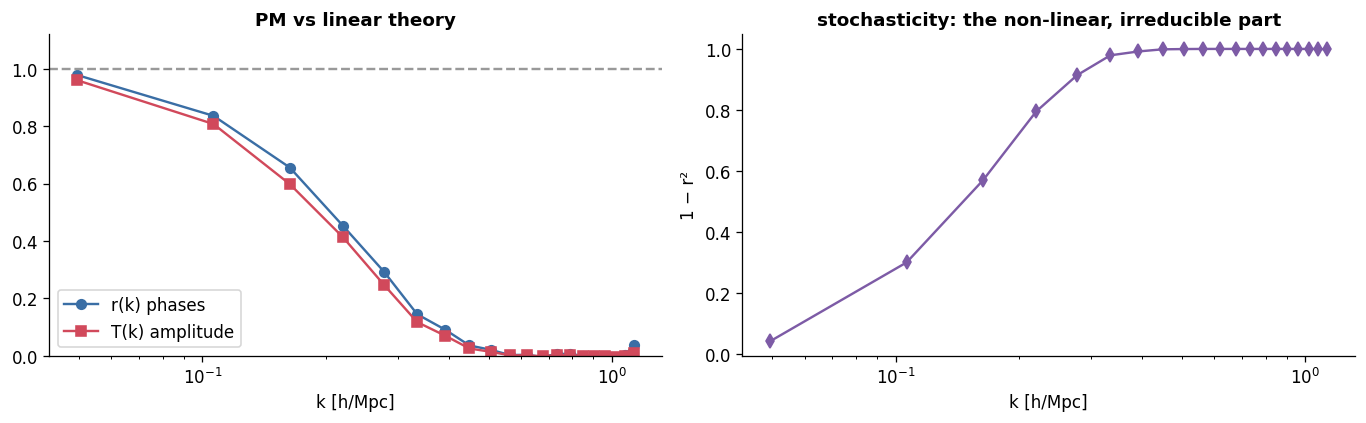

large scales:  r=0.978  T=0.960


In [3]:
from oneuniverse.simulation.validation import validate_field
v=validate_field(fields[-1],ic,box=BOX)
fig,ax=plt.subplots(1,2,figsize=(12,3.8))
ax[0].semilogx(v.k,v.r,'o-',color=C0,label='r(k) phases')
ax[0].semilogx(v.k,v.transfer,'s-',color=C1,label='T(k) amplitude')
ax[0].axhline(1,color='.6',ls='--'); ax[0].set_ylim(0,1.12)
ax[0].set_xlabel('k [h/Mpc]'); ax[0].legend(); ax[0].set_title('PM vs linear theory')
ax[1].semilogx(v.k,v.stochasticity,'d-',color=C4)
ax[1].set_xlabel('k [h/Mpc]'); ax[1].set_ylabel('1 − r²')
ax[1].set_title('stochasticity: the non-linear, irreducible part')
plt.tight_layout(); plt.show()
lo=v.k<0.06
print('large scales:  r=%.3f  T=%.3f'%(np.nanmedian(v.r[lo]),np.nanmedian(v.transfer[lo])))

## The TreePM force split — the idea, drawn
Split gravity in Fourier space: the **long-range tide** comes from the full-box linear field (low-pass, scaled by D(a)); the **short-range** force from the tile's own PM (high-pass). The two filters are exactly complementary, so nothing is double-counted.

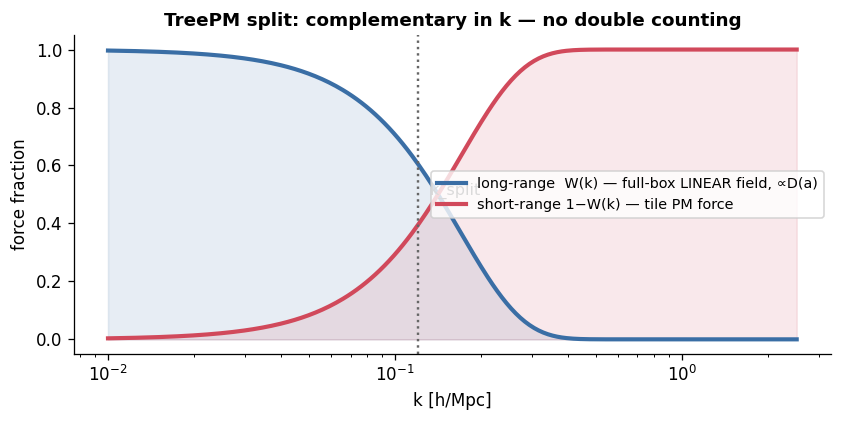

In [4]:
kk=np.logspace(-2,0.4,300); ks=0.12
W=np.exp(-0.5*(kk/ks)**2)
fig,ax=plt.subplots(figsize=(8.5,3.6))
ax.semilogx(kk,W,lw=2.6,color=C0,label='long-range  W(k) — full-box LINEAR field, ∝D(a)')
ax.semilogx(kk,1-W,lw=2.6,color=C1,label='short-range 1−W(k) — tile PM force')
ax.fill_between(kk,0,W,color=C0,alpha=.12); ax.fill_between(kk,0,1-W,color=C1,alpha=.12)
ax.axvline(ks,color='.4',ls=':',lw=1.5); ax.text(ks*1.1,0.5,'k_split',fontsize=10,color='.3')
ax.set_xlabel('k [h/Mpc]'); ax.set_ylabel('force fraction')
ax.set_title('TreePM split: complementary in k — no double counting')
ax.legend(fontsize=9, loc='center right'); plt.show()

## Does it pay? Buffer convergence
Inner-region fidelity vs buffer size, naive uncoupled tile vs TreePM-coupled tile, against a full-box reference.

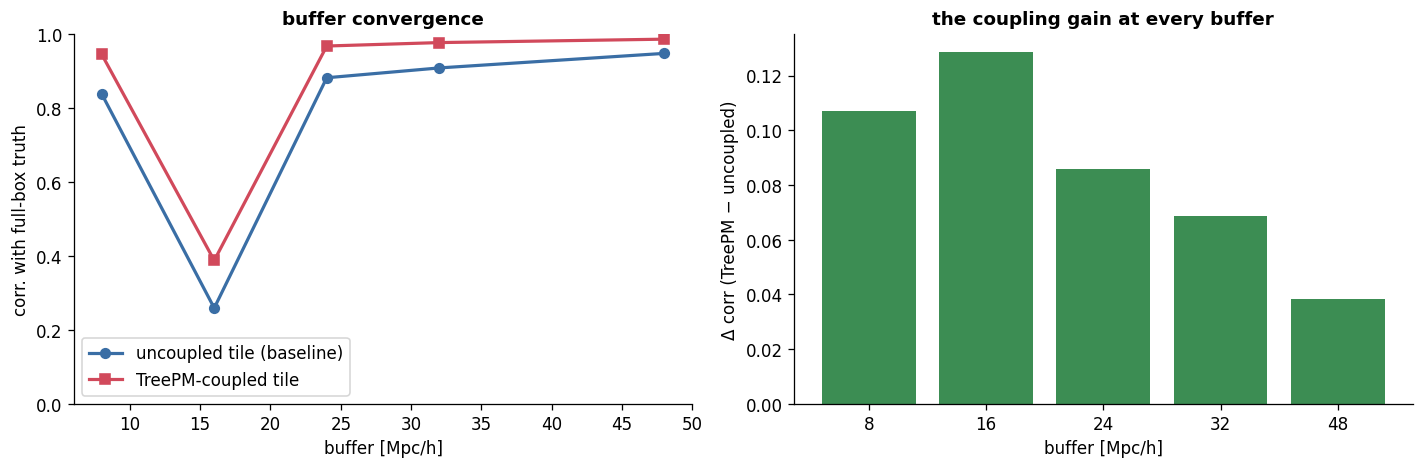

TreePM@8 (0.95) vs uncoupled@48 (0.95) — comparable accuracy at a much smaller buffer


In [5]:
from oneuniverse.simulation.resim.bench import reference_inner, uncoupled_resim_fn
from oneuniverse.simulation.resim.treepm import run_coupled_treepm
KW=dict(box=300.0,n_grid=64,target_lo=112.0,target_side=76.0,seed=4,n_steps=18)
ref=reference_inner(COSMO,**KW)
unc=uncoupled_resim_fn(COSMO,**KW)
tp=lambda b: run_coupled_treepm(COSMO,ic,box=KW['box'],n_grid=KW['n_grid'],
    target_lo=KW['target_lo'],target_side=KW['target_side'],buffer=b,
    z_start=9.0,z_end=0.0,n_steps=KW['n_steps'])['inner']
co=lambda a: float(np.corrcoef(a.ravel(),ref.ravel())[0,1])
buffers=[8.,16.,24.,32.,48.]
cu=[co(unc(b)) for b in buffers]; ct=[co(tp(b)) for b in buffers]
fig,ax=plt.subplots(1,2,figsize=(12.5,4.2))
ax[0].plot(buffers,cu,'o-',color=C0,lw=2,label='uncoupled tile (baseline)')
ax[0].plot(buffers,ct,'s-',color=C1,lw=2,label='TreePM-coupled tile')
ax[0].set_xlabel('buffer [Mpc/h]'); ax[0].set_ylabel('corr. with full-box truth')
ax[0].set_ylim(0,1); ax[0].legend(); ax[0].set_title('buffer convergence')
gains=[t-u for t,u in zip(ct,cu)]
ax[1].bar([str(int(b)) for b in buffers],gains,color=C2)
ax[1].set_xlabel('buffer [Mpc/h]'); ax[1].set_ylabel('Δ corr (TreePM − uncoupled)')
ax[1].set_title('the coupling gain at every buffer')
plt.tight_layout(); plt.show()
print('TreePM@%g (%.2f) vs uncoupled@%g (%.2f) — comparable accuracy at a much smaller buffer'
      %(buffers[0],ct[0],buffers[-1],cu[-1]))

**What this showed.** The PM solver grows structure on the exact linear-theory curve and recovers phases+amplitude at large scales; the resimulation problem is the missing large-scale tide; and the scale-split force closes most of that gap at every buffer size — the economics that make selective zoom resimulation viable.